# Poster Visualization

## Performance vs. Iteration

Working...


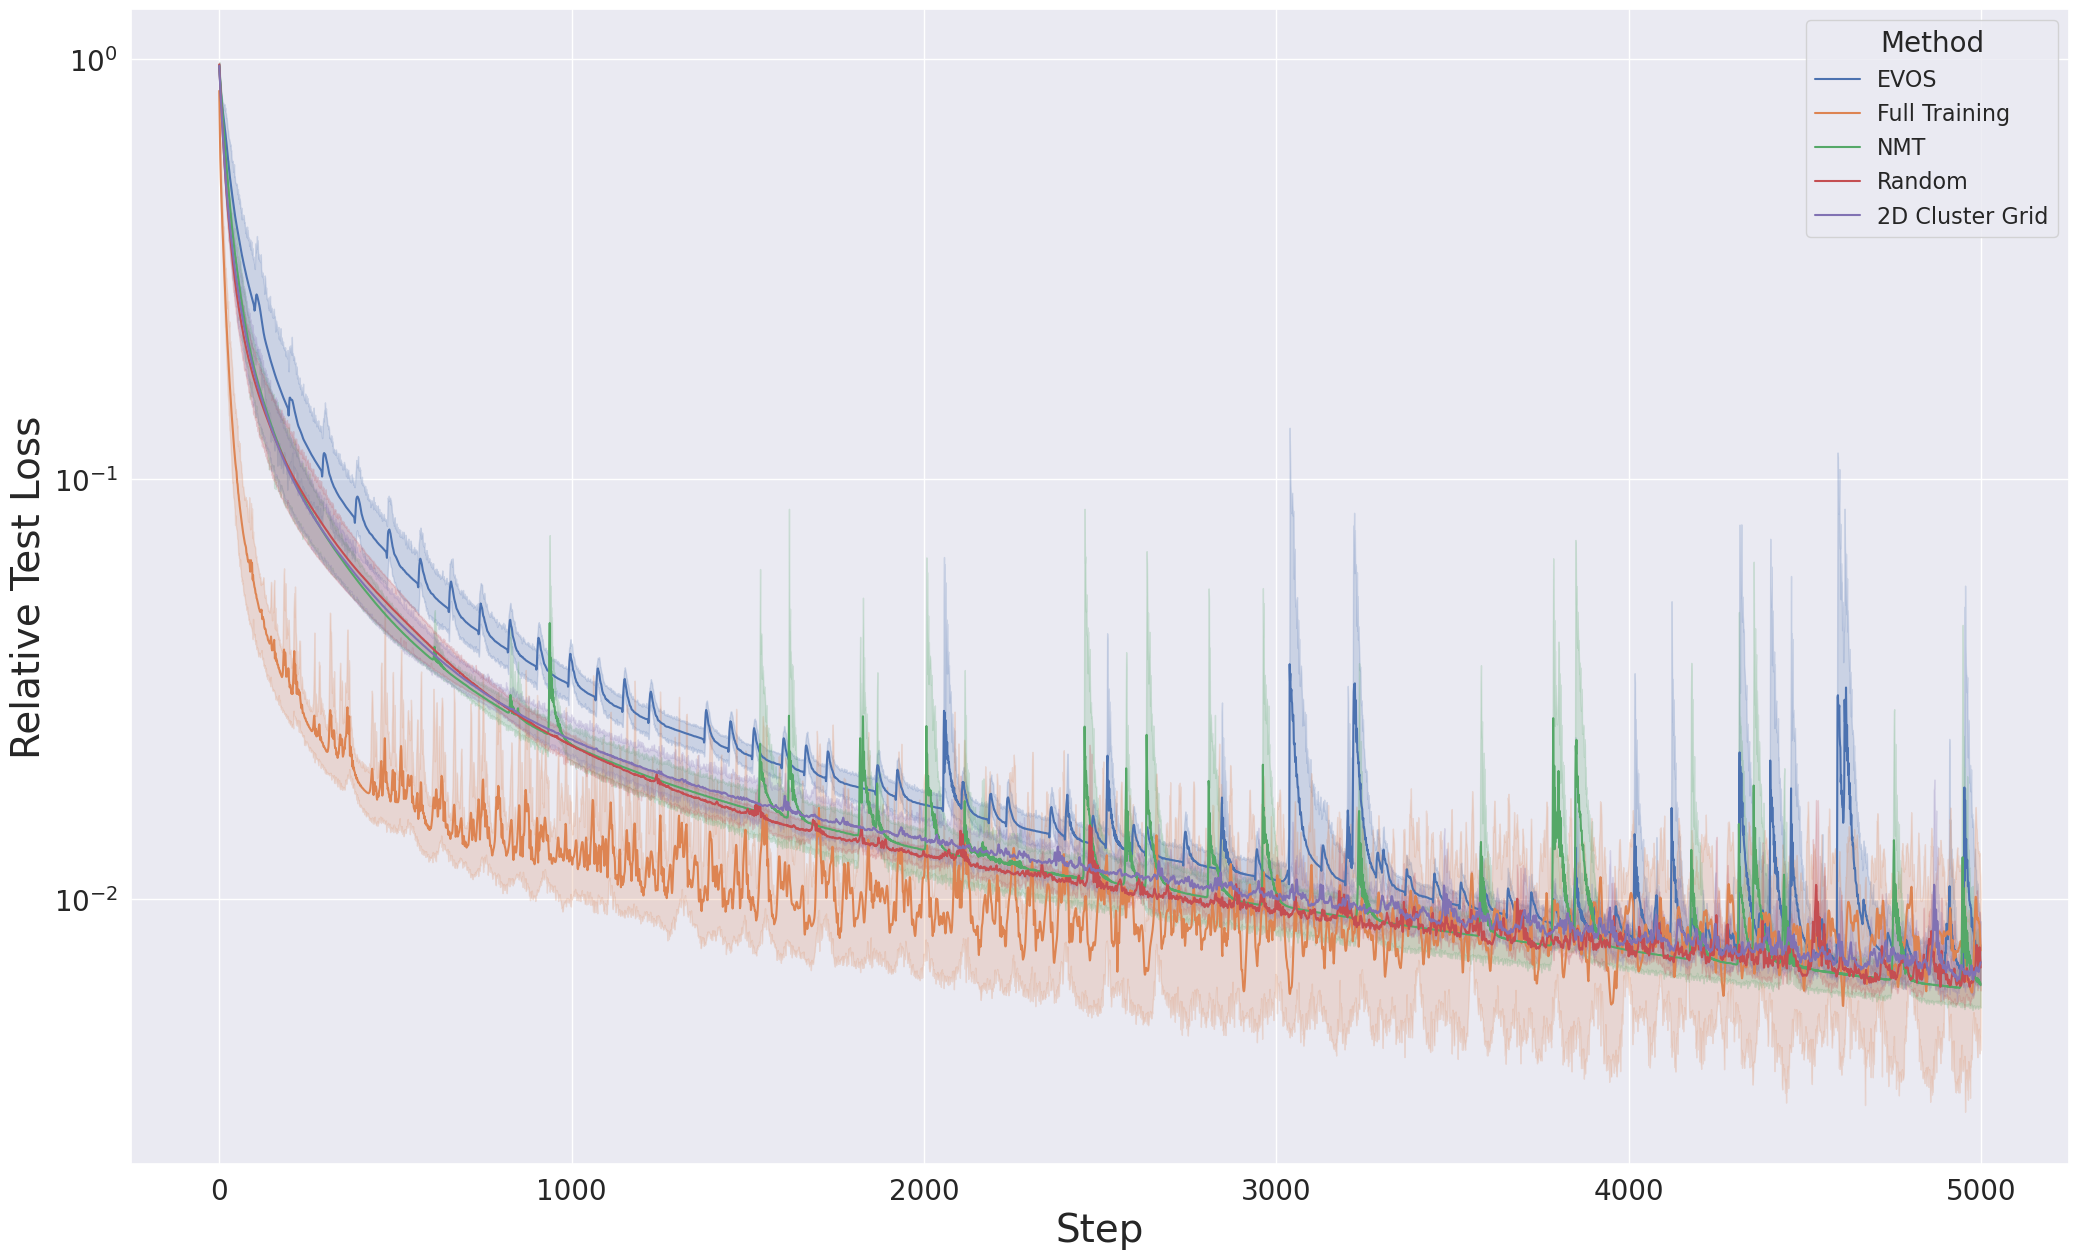

In [4]:
import statistics
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pylab as pylab

var_count = {"evos": 0, "none": 0, "nmt": 0, "random": 0, "2d_cluster_grid": 0}
losses = {"evos": [], "none": [], "nmt": [], "random": [], "2d_cluster_grid": []}
times = {"evos": [], "none": [], "nmt": [], "random": [], "2d_cluster_grid": []}
steps = {"evos": [], "none": [], "nmt": [], "random": [], "2d_cluster_grid": []}
bottom_variance = {"evos": [], "none": [], "nmt": [], "random": [], "2d_cluster_grid": []}
top_variance = {"evos": [], "none": [], "nmt": [], "random": [], "2d_cluster_grid": []}
mean_loss = {"evos": [], "none": [], "nmt": [], "random": [], "2d_cluster_grid": []}
hist_list = []


print("Working...")
with open('/sdcc/u/smccue/projects/inr_sampling/visuals/out.txt') as f:
    vals = ("trl", "time", "step")
    cur_val = ""
    method = ""
    for line in f:
        line = line.rstrip('\n')
        # print(line)
        if line.lower() in var_count.keys():
            method = line.lower()
            var_count[method]+=1
        elif line in vals:
            cur_val = line
        else:
            if cur_val == "trl":
                losses[method].append([float(x) for x in line.split(',')])
            elif cur_val == "time":
                times[method] = [float(x) for x in line.split(',')]
            elif cur_val == "step":
                if method == "evos":
                    steps[method] = [int(x)-1 for x in line.split(',')]
                else:
                    steps[method] = [int(x) for x in line.split(',')]
            else:
                print("~~~ERROR~~~")
                print(cur_val)
                break

all_run = []
all_run_time = []
for m in var_count.keys():
    # 1) turn into a (9, n_steps) array
    arr = np.array(losses[m])         # shape (9, n_steps)
    
    # 2) build a wide‐form DataFrame: rows=steps, cols=runs
    df_wide = pd.DataFrame(
        arr.T,                     # shape (n_steps, 9)
        columns=[f"run_{i}" for i in range(len(losses[m]))]
    )
    df_wide["step"] = steps[m]

    tf_wide = pd.DataFrame(
        arr.T,
        columns=[f"run_{i}" for i in range(len(losses[m]))]
    )
    tf_wide["time"] = times[m]
    
    # 3) melt to long form: one row per (step, run, loss)
    df_long = df_wide.melt(
        id_vars="step",
        value_vars=[f"run_{i}" for i in range(len(losses[m]))],
        var_name="run",
        value_name="loss"
    )

    tf_long = tf_wide.melt(
        id_vars="time",
        value_vars=[f"run_{i}" for i in range(len(losses[m]))],
        var_name="run",
        value_name="loss"
    )
    
    df_long["method"] = ([m] * (steps[m][-1] + 1)) * len(losses[m])
    tf_long["method"] = ([m] * (steps[m][-1] + 1)) * len(losses[m])
    all_run.append(df_long)
    all_run_time.append(tf_long)
    
df_final = pd.concat(all_run, ignore_index=True)
tf_final = pd.concat(all_run_time, ignore_index=True)
    
plt.figure(figsize=(25,15))
sns.set_theme()
p = sns.lineplot(
    data     = df_final,
    x        = "step",
    y        = "loss",
    errorbar = ('ci', 100),     # or ci=95 on older seaborn
    hue="method",
)

new_labels = ['EVOS', 'Full Training', 'NMT', 'Random', '2D Cluster Grid']
L=plt.legend(fontsize=16, title_fontsize=20)
L.get_texts()[0].set_text(new_labels[0])
L.get_texts()[1].set_text(new_labels[1])
L.get_texts()[2].set_text(new_labels[2])
L.get_texts()[3].set_text(new_labels[3])
L.get_texts()[4].set_text(new_labels[4])
p.legend_.set_title("Method")
plt.xlabel("Step", fontsize=28)
plt.ylabel("Relative Test Loss", fontsize=28)
# plt.title("Performance Over Steps", fontsize=38)

plt.xticks(fontsize=20)  # or whatever size you prefer
plt.yticks(fontsize=20)
plt.yscale('log')



plt.show()

## Performance vs. Time

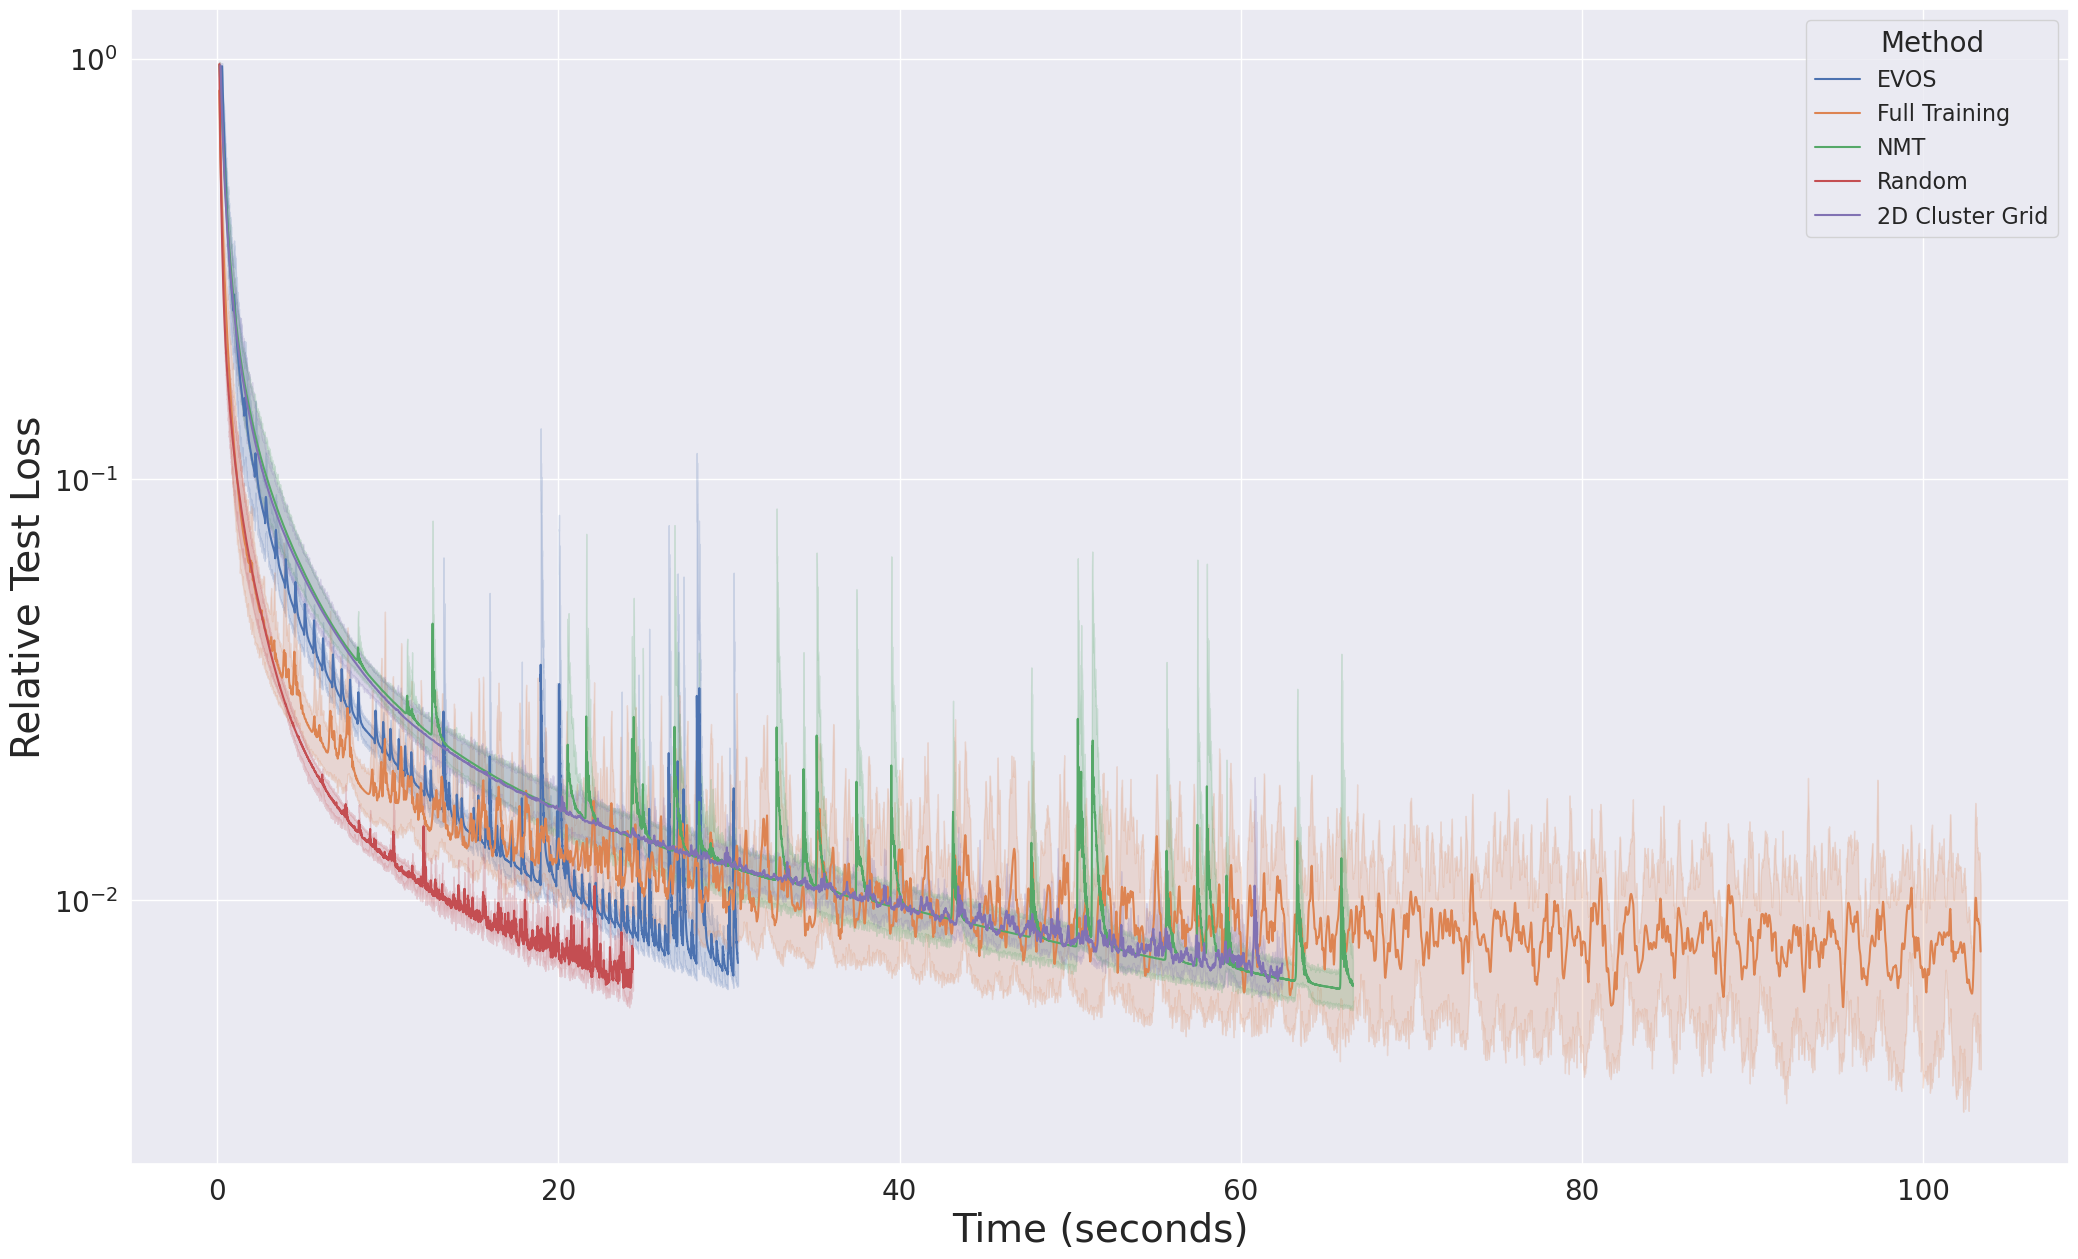

In [5]:
plt.figure(figsize=(25,15))
sns.set_theme()
tplot = sns.lineplot(
    data     = tf_final,
    x        = "time",
    y        = "loss",
    errorbar = ('ci', 100),     # or ci=95 on older seaborn
    hue="method",
)

new_labels = ['EVOS', 'Full Training', 'NMT', 'Random', '2D Cluster Grid']
L=plt.legend(fontsize=16, title_fontsize=20)
L.get_texts()[0].set_text(new_labels[0])
L.get_texts()[1].set_text(new_labels[1])
L.get_texts()[2].set_text(new_labels[2])
L.get_texts()[3].set_text(new_labels[3])
L.get_texts()[4].set_text(new_labels[4])
tplot.legend_.set_title("Method")
plt.xlabel("Time (seconds)", fontsize=28)
plt.ylabel("Relative Test Loss", fontsize=28)
plt.yscale('log')
# plt.title("Performance Over Time", fontsize=38)

plt.xticks(fontsize=20)  # or whatever size you prefer
plt.yticks(fontsize=20)
 
plt.show()